In [22]:
# align_templates.py
from modeller import *

env = Environ()
aln = Alignment(env)

for pdb_id, chain in (('1TBB_nohetatm', 'B'), ('PDE4B', 'A')):
    mdl = Model(env, file=pdb_id, model_segment=('FIRST:'+chain, 'LAST:'+chain))
    aln.append_model(mdl, atom_files=pdb_id, align_codes=pdb_id+chain)

aln.salign()
aln.write(file='templates.pir', alignment_format='PIR')
aln.write(file='templates.ali', alignment_format='PIR')  # backup


SALIGN_____> adding the next group to the alignment; iteration    1


In [ ]:
# align_target_to_each.py
from modeller import *

env = Environ()

# Target vs 1TBB_nohetatm PDE4D catalytic domain region
aln1 = Alignment(env)
mdl = Model(env, file='1TBB_nohetatm', model_segment=('FIRST:B','LAST:B'))
aln1.append_model(mdl, align_codes='1TBB_nohetatm', atom_files='1TBB_nohetatm')
aln1.append(file='target.fasta', alignment_format='FASTA', align_codes='target')
aln1.align2d()
aln1.write(file='target-1TBB_nohetatm.pir', alignment_format='PIR')

# Target vs PDE4B (long form, UCR1/UCR2 + catalytic domain)
aln2 = Alignment(env)
mdl = Model(env, file='PDE4B', model_segment=('FIRST:A','LAST:A'))
aln2.append_model(mdl, align_codes='PDE4B', atom_files='PDE4B')
aln2.append(file='target.fasta', alignment_format='FASTA', align_codes='target')
aln2.align2d()
aln2.write(file='target-PDE4B.pir', alignment_format='PIR')

mkapsa__637W> No residue topology library is in memory.
              Better radii would be used if topology.read() is called first.
iup2crm_280W> No topology library in memory or assigning a BLK residue.
              Default CHARMM atom type assigned:  N -->  N
              This message is written only for the first such atom.

Pairwise dynamic programming alignment (ALIGN2D):
  Residue-residue metric   : $(LIB)/as1.sim.mat
  Diagonal                 :          100
  Overhang                 :            0
  Maximal gap length       :       999999
  Local alignment          :            F
  MATRIX_OFFSET (local aln):       0.0000
  FIX_OFFSETS              :      0.0    -1.0    -2.0    -3.0    -4.0
  N_SUBOPT                 :            0
  SUBOPT_OFFSET            :       0.0000
  Alignment block          :            1
  Gap introduction penalty :    -100.0000
  Gap extension penalty    :       0.0000
  Gap diagonal penalty     :       0.0000
  Structure gap penalties  :    3.500

In [26]:
from modeller import *

In [ ]:
from modeller import *
from modeller.automodel import *

class MyModel(loopmodel):

    def select_loop_atoms(self):
        return Selection(self.residue_range('207:A', '209:A'))

    def special_restraints(self, aln):
        rsr = self.restraints

        # resíduos distantes do loop -> restringir backbone inteiro (mais rígido)
        residuos_distantes = [
            '72:A', '73:A', 
            '186:A', '234:A', '242:A',
            '245:A', '246:A', '249:A',
            '250:A', '253:A', '270:A',
            '281:A', '282:A', '285:A'
        ]

        def tether_atoms(res_ids, atom_names, stdev):
            for r in res_ids:
                res = self.residues[r]
                for atom_name in atom_names:
                    if atom_name in res.atoms:
                        atom = res.atoms[atom_name]
                        rsr.add(
                            forms.Gaussian(
                                group=physical.xy_distance,
                                feature=features.Distance(atom, atom),
                                mean=0.0,
                                stdev=stdev
                            )
                        )

        # distantes: backbone inteiro, mola mais rígida
        tether_atoms(residuos_distantes, ('N', 'CA', 'C', 'O'), stdev=0.05)


a = MyModel(
    env,
    alnfile  = 'combined.pir',
    knowns   = ('1TBB_nohetatm', 'PDE4B'),
    sequence = 'target'    
)
 
a.starting_model = 1
a.ending_model   = 1

a.loop.starting_model = 1
a.loop.ending_model   = 50             
a.loop.md_level       = refine.very_slow 

a.make()

loopmodel__W> The class 'loopmodel' is deprecated; use 'LoopModel' instead

check_ali___> Checking pairwise structural superpositions. 

Equivalent CA pairs with distance difference larger than  6.0 angstroms:

ALN_POS TMPL1 TMPL2  RID1  RID2  NAM1  NAM2     DIST
----------------------------------------------------
      3     1     2    0     3      E     P   50.159
      4     1     2    1     4      Q     F   48.210
      5     1     2    2     5      E     A   50.184
      6     1     2    3     6      D     Q   48.957
      7     1     2    4     7      V     V   45.183
      8     1     2    5     8      L     L   45.458
      9     1     2    6     9      A     A   46.670
     22     1     2    7    22      K     T   52.970
     23     1     2    8    23      E     N   54.869
     24     1     2    9    24      L     L   54.698
     25     1     2   10    25      E     H   56.272
     26     1     2   11    26      D     G   54.320
     41     1     2   12    40      V     V   7

In [32]:
from modeller import *
from modeller.scripts import complete_pdb
import glob
import os

log.verbose()
env = Environ()
env.libs.topology.read(file='$(LIB)/top_heav.lib')
env.libs.parameters.read(file='$(LIB)/par.lib')

modelling_dir = '.'

# Get files
model_files = sorted(
    glob.glob(os.path.join(modelling_dir, 'target.BL*.pdb'))
)

openf___224_> Open           $(LIB)/restyp.lib
openf___224_> Open           ${MODINSTALL10v8}/modlib/restyp_cif.lib
openf___224_> Open           ${MODINSTALL10v8}/modlib/resgrp.lib
rdresgr_266_> Number of residue groups:        2
openf___224_> Open           ${MODINSTALL10v8}/modlib/sstruc.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     17248605   16844.340    16.450

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     17249133   16844.855    16.450
openf___224_> Open           ${MODINSTALL10v8}/modlib/resdih.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     17297733   16892.316    16.496
rdrdih__263_> Number of dihedral angle types         :        9
              Maximal number of dihedral angle optima:        3
              Dihedral angle names                   :  Alph Phi Psi Omeg chi1 chi2 chi3 chi4 chi5
openf___224_> Open           ${MODINSTALL10v8}/modlib/radii.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,Mi

In [33]:
len(model_files)

50

In [34]:
scores = []

# Save scores and profiles
for model_path in model_files:
    base_name = os.path.splitext(os.path.basename(model_path))[0]
    profile_file = os.path.join(modelling_dir, f'{base_name}.profile')
       
    mdl = complete_pdb(env, model_path)
    s = Selection(mdl)
    
    score = s.assess_dope()
    scores.append((score, base_name, profile_file))
    
    s.assess_dope(output='ENERGY_PROFILE NO_REPORT',
                  file=profile_file,
                  normalize_profile=True,
                  smoothing_window=15)

openf___224_> Open           ./target.BL00010001.pdb

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:     17499454   17089.311    16.689

Dynamically allocated memory at    amaxsequence [B,KiB,MiB]:     17499530   17089.385    16.689

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:     17499701   17089.551    16.689

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:     17500551   17090.383    16.690

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:     17501809   17091.609    16.691

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:     17503713   17093.469    16.693

Dynamically allocated memory at    amaxsequence [B,KiB,MiB]:     17503753   17093.508    16.693

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:     17503843   17093.598    16.693

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:     17506699   17096.387    16.696

Dynamically allocated memory at    amaxsequence [B,KiB,MiB]:     17506759

In [36]:

# Ranking final
print("\n Ranking - DOPE score")
for score, name, profile in sorted(scores[1:50]):
    print(f"  {name:40s}  DOPE: {score:.2f}")

best = sorted(scores)[0]
print(f"\nBest: {best[1]}  (DOPE: {best[0]:.2f})")



 Ranking - DOPE score
  target.BL00470001                         DOPE: -50814.91
  target.BL00270001                         DOPE: -50814.77
  target.BL00320001                         DOPE: -50813.60
  target.BL00050001                         DOPE: -50811.16
  target.BL00230001                         DOPE: -50807.41
  target.BL00170001                         DOPE: -50804.45
  target.BL00300001                         DOPE: -50800.05
  target.BL00290001                         DOPE: -50800.00
  target.BL00030001                         DOPE: -50799.99
  target.BL00350001                         DOPE: -50799.76
  target.BL00330001                         DOPE: -50799.27
  target.BL00260001                         DOPE: -50797.54
  target.BL00080001                         DOPE: -50796.88
  target.BL00150001                         DOPE: -50796.14
  target.BL00250001                         DOPE: -50795.71
  target.BL00120001                         DOPE: -50794.05
  target.BL004200

In [37]:
sorted(scores)[:10]

[(-50824.5, 'target.BL00010001', './target.BL00010001.profile'),
 (-50814.9140625, 'target.BL00470001', './target.BL00470001.profile'),
 (-50814.765625, 'target.BL00270001', './target.BL00270001.profile'),
 (-50813.6015625, 'target.BL00320001', './target.BL00320001.profile'),
 (-50811.15625, 'target.BL00050001', './target.BL00050001.profile'),
 (-50807.4140625, 'target.BL00230001', './target.BL00230001.profile'),
 (-50804.4453125, 'target.BL00170001', './target.BL00170001.profile'),
 (-50800.0546875, 'target.BL00300001', './target.BL00300001.profile'),
 (-50800.0, 'target.BL00290001', './target.BL00290001.profile'),
 (-50799.9921875, 'target.BL00030001', './target.BL00030001.profile')]

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
import re
import numpy as np

#modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/target/1-loopmodelling'
modelling_dir = "."
profiles_with_sum = []
profile_files = sorted(glob.glob(os.path.join(modelling_dir, '*.profile')))
for profile_path in profile_files:
    total_sum = None
    with open(profile_path, 'r') as f:
        for line in f:
            match = re.search(r'The sum of all numbers in the file:\s+([-\d.]+)', line)
            if match:
                total_sum = float(match.group(1))
                break
    
    profiles_with_sum.append((profile_path, total_sum))

# Sort from smaller to bigger
profiles_with_sum.sort(key=lambda x: x[1], reverse=True)
top10 = profiles_with_sum[-10:]  # Last 1o (smaller values)

In [39]:
top10

[('./target.BL00250001.profile', -16.7173),
 ('./target.BL00290001.profile', -16.7175),
 ('./target.BL00030001.profile', -16.7176),
 ('./target.BL00330001.profile', -16.7181),
 ('./target.BL00170001.profile', -16.7193),
 ('./target.BL00270001.profile', -16.7216),
 ('./target.BL00470001.profile', -16.7226),
 ('./target.BL00320001.profile', -16.7234),
 ('./target.BL00050001.profile', -16.7239),
 ('./target.BL00010001.profile', -16.7257)]

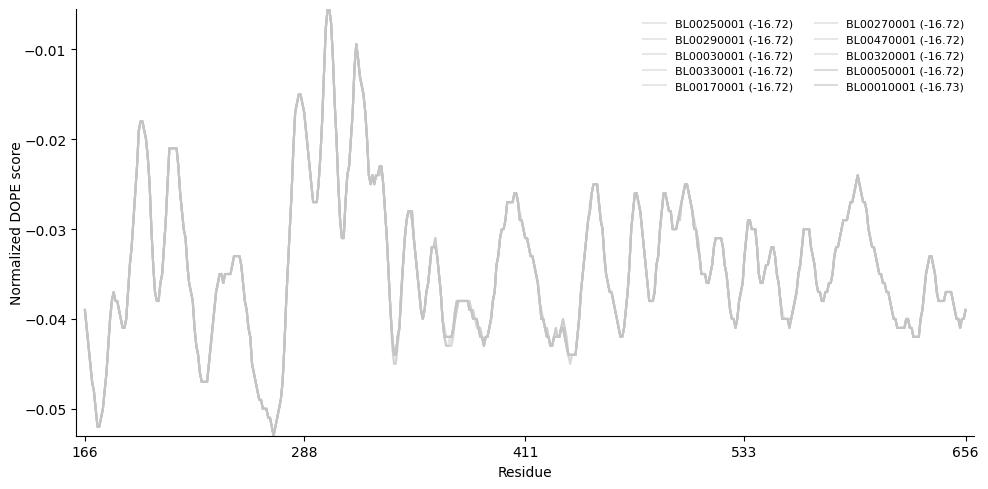

In [40]:

cinza = "#c4c4c4"
verde = '#6FAF9C'
roxo = '#A665B5'
# colors = [cinza] * 8 + [verde] * 2
colors = [cinza] *10

plt.figure(figsize=(10, 5))

all_dope = []
for i, (profile_path, total_sum) in enumerate(top10):

    name = os.path.basename(profile_path).replace('.profile', '').replace('target.', '')
    df = pd.read_csv(profile_path, sep='\s+', comment='#', header=None)
    residues = df[0] + 165
    dope=df[df.columns[-1]]
    all_dope.extend(dope.tolist())
    label = f'{name} ({round(total_sum, 2)})'    

    if i == 9 or i == 8:
        alpha = 0.6
    else:
        alpha = 0.4

    plt.plot(residues, dope, label=label, color=colors[i], alpha=alpha, )

# Scaling
plt.ylim(min(all_dope), max(all_dope))

plt.xlabel('Residue')
plt.ylabel('Normalized DOPE score', labelpad=0)

plt.title('')
plt.legend(fontsize=8,frameon=False, ncol=2)
ax = plt.gca()
plt.margins(x=0.01)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

first = residues.iloc[0]
last = residues.iloc[-1]
ticks = [first] + list(np.linspace(first, last, 5).astype(int)[1:-1]) + [last]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks)

plt.tight_layout()
#plt.savefig(os.path.join(modelling_dir, 'dope_profiles.png'), dpi=150)
plt.show() 

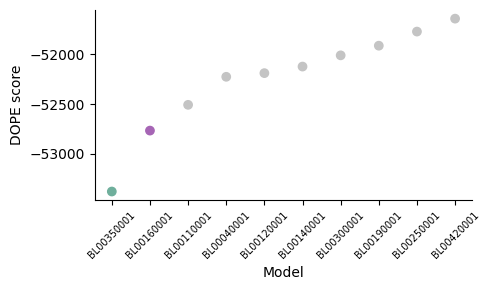

In [11]:
import matplotlib.pyplot as plt

# Ordenar do pior para o melhor (melhor fica à direita)
scores_sorted = sorted(scores, key=lambda x: x[0], reverse=False)
top10_scores = scores_sorted[:10]

names = [s[1].replace('target.', '').replace('.pdb', '') for s in top10_scores]

dopes = [s[0] for s in top10_scores]

# Destacar o melhor (último)
colors = [verde] + [roxo] + [cinza] * 8

fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(range(len(top10_scores)), dopes, color=colors, zorder=3)

ax.set_xlabel('Model')
ax.set_ylabel('DOPE score')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, fontsize=7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig(os.path.join(modelling_dir, 'dope_total.png'), dpi=150)
plt.show()

In [44]:
def renumber_pdb(input_pdb, output_pdb, start):
    with open(input_pdb, 'r') as f:
        lines = f.readlines()
    
    current_resnum = None
    new_resnum = start - 1
    
    with open(output_pdb, 'w') as out:
        for line in lines:
            if line.startswith(('ATOM', 'HETATM')):
                res = line[22:26].strip()
                if res != current_resnum:
                    current_resnum = res
                    new_resnum += 1
                line = line[:22] + f'{new_resnum:4d}' + line[26:]
            out.write(line)

modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/modeller_join/'

In [45]:
renumber_pdb(
        input_pdb="/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/modeller_join/target.B99990042.pdb",
        output_pdb=modelling_dir + f"modelo_42.pdb",
        start=216
    )

In [ ]:
env = environ()
aln = alignment(env)
mdl = model(env, file='template')
aln.append_model(mdl, align_codes='template', atom_files='template.pdb')
aln.append(file='target.ali', align_codes='target')
aln.align2d()  # alinhamento baseado em estrutura, melhor que align()
aln.write(file='aln_refined.ali')